In [48]:
! pip install "granite-tsfm[notebooks]==0.3.1"
! pip install gdown


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [49]:
import math
import os
import joblib

import numpy as np
import pandas as pd
import torch
import evaluate
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset
from transformers import set_seed

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

from tsfm_public.models.tspulse import TSPulseForReconstruction
from tsfm_public.toolkit.time_series_preprocessor import (
    TimeSeriesPreprocessor,
    get_datasets,
)

## Load data from carOBD

In [50]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['filename'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


## Remove zero-variance columns

In [51]:
def remove_zero_variance_columns(df: pd.DataFrame) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  std_df = df.std(numeric_only=True)

  zero_variance_cols = std_df[std_df == 0].index.tolist()
  print(f'{len(zero_variance_cols)} columns with zero variance')

  if len(zero_variance_cols) > 0:
    df = df.drop(columns=zero_variance_cols)

  return df

## Handle missing Timestamps and duplicates

In [52]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  df = df.groupby(time_col, as_index=False).mean(numeric_only=True)
  return df

## Inject Anomalies

In [53]:
from faults import create_realistic_fault_data

## Process Data

In [54]:
target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

print("Processing all files and combining into single DataFrame...")
dfs = []
skipped_files = []

for drive_idx, df in enumerate(df_list):
    df_clean = mean_fill_missing_timestamps_and_remove_duplicates(df)
    
    missing_cols = [col for col in target_columns if col not in df_clean.columns]
    if missing_cols:
        print(f"⚠️  File {drive_idx} missing columns: {missing_cols}")
        skipped_files.append(drive_idx)
        continue
    
    if time_col not in df_clean.columns:
        print(f"⚠️  File {drive_idx} missing timestamp column: {time_col}")
        skipped_files.append(drive_idx)
        continue
    
    # Add drive_id to identify each time series
    df_clean['drive_id'] = drive_idx

    required_cols = [time_col, 'drive_id'] + target_columns
    df_clean = df_clean[required_cols].copy()
    
    if not pd.api.types.is_numeric_dtype(df_clean[time_col]):
        df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    
    df_clean = df_clean.dropna(subset=[time_col] + target_columns)
    
    if len(df_clean) == 0:
        print(f"⚠️  File {drive_idx} has no valid data after cleaning")
        skipped_files.append(drive_idx)
        continue
    
    dfs.append(df_clean)
    print(f"✓ File {drive_idx}: {len(df_clean)} samples")

# Combine all dataframes
if len(dfs) == 0:
    raise ValueError("No valid data files found!")

data = pd.concat(dfs, ignore_index=True)

print(f"\n{'='*60}")
print(f"Data Summary:")
print(f"{'='*60}")
print(f"Total files processed: {len(dfs)}")
print(f"Skipped files: {len(skipped_files)}")
print(f"Total rows: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")
print(f"Columns: {list(data.columns)}")
print(f"\nData shape: {data.shape}")

Processing all files and combining into single DataFrame...
✓ File 0: 617 samples
✓ File 1: 722 samples
✓ File 2: 512 samples
✓ File 3: 1111 samples
✓ File 4: 350 samples
✓ File 5: 397 samples
✓ File 6: 619 samples
✓ File 7: 626 samples
✓ File 8: 957 samples
✓ File 9: 349 samples
✓ File 10: 504 samples
✓ File 11: 265 samples
✓ File 12: 368 samples
✓ File 13: 1041 samples
✓ File 14: 1482 samples
✓ File 15: 343 samples
✓ File 16: 837 samples
✓ File 17: 640 samples
✓ File 18: 1099 samples
✓ File 19: 2039 samples
✓ File 20: 576 samples
✓ File 21: 1029 samples
✓ File 22: 346 samples
✓ File 23: 885 samples
✓ File 24: 297 samples
✓ File 25: 215 samples
✓ File 26: 656 samples
✓ File 27: 1176 samples
✓ File 28: 1646 samples
✓ File 29: 305 samples
✓ File 30: 198 samples
✓ File 31: 516 samples
✓ File 32: 328 samples
✓ File 33: 762 samples
✓ File 34: 311 samples
✓ File 35: 519 samples
✓ File 36: 1259 samples
✓ File 37: 903 samples
✓ File 38: 1591 samples
✓ File 39: 755 samples
✓ File 40: 474 sampl

## Data Split and Fault Injection

In [55]:
from torch.utils.data import DataLoader, Dataset

data['drive_id'] = data['drive_id'].astype(str)
all_drive_ids = data['drive_id'].unique()
train_ids = all_drive_ids[:int(0.7 * len(all_drive_ids))]
val_ids = all_drive_ids[int(0.7 * len(all_drive_ids)):int(0.85 * len(all_drive_ids))]
test_ids = all_drive_ids[int(0.85 * len(all_drive_ids)):]

train_data = data[data['drive_id'].isin(train_ids)]
val_data = data[data['drive_id'].isin(val_ids)]
test_data = data[data['drive_id'].isin(test_ids)]

tsp = TimeSeriesPreprocessor(
    timestamp_column=time_col,
    id_columns=['drive_id'],
    target_columns=target_columns,
    control_columns=[],
    context_length=512,
    prediction_length=16, # from 96
    scaling=True,
    scaling_id_columns=[],
    scaling_type="robust" # from standard
)

tsp = tsp.train(train_data)

def inject_faults_into_test_set(df_clean, target_columns, fault_percentage=0.15, random_state=42):
    df_faulty = df_clean.copy()
    numeric_cols = [col for col in target_columns if col in df_faulty.columns]
    data_array = df_faulty[numeric_cols].values
    
    fault_features, fault_labels, _ = create_realistic_fault_data(
        normal_data=data_array,
        fault_percentage=fault_percentage,
        random_state=random_state
    )
    
    df_faulty[numeric_cols] = fault_features
    df_faulty['is_anomaly'] = fault_labels
    return df_faulty, fault_labels

test_data_faulty, test_labels = inject_faults_into_test_set(test_data, target_columns, 0.20, 42)

class FilteredForecastDataset(Dataset):
    """Wrapper that filters ForecastDFDataset to only tensor keys"""
    def __init__(self, forecast_dataset):
        self.dataset = forecast_dataset
        # Only keep keys needed for TSPulseForReconstruction
        self.keys_to_keep = ['past_values', 'past_observed_mask']
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        # Filter to only tensor-compatible keys
        filtered = {k: v for k, v in sample.items() if k in self.keys_to_keep}
        return filtered


dset_train, _, _ = get_datasets(
    tsp,
    train_data,
    split_config={"train": 1.0, "test": 0.0},
)

dset_val, _, _ = get_datasets(
    tsp,
    val_data,
    split_config={"train": 1.0, "test": 0.0},
)

dset_test, _, _ = get_datasets(
    tsp,
    test_data_faulty,
    split_config={"train": 1.0, "test": 0.0},
)

dset_train = FilteredForecastDataset(dset_train)
dset_val = FilteredForecastDataset(dset_val)
dset_test = FilteredForecastDataset(dset_test)

print(f"Train: {len(dset_train)} windows (clean)")
print(f"Val: {len(dset_val)} windows (clean)")
print(f"Test: {len(dset_test)} windows (with faults)")


Train: 17215 windows (clean)
Val: 4134 windows (clean)
Test: 2287 windows (with faults)


## Metrics

In [56]:
from evaluate import load

metric = load("f1")

## Model Init

In [63]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    revision="main",
    context_length=512,
    prediction_length=16,
    mode="mix_channel",
    num_input_channels=tsp.num_input_channels,
    scaling='revin',
    mask_type='hybrid',

)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
num_epochs = 100

INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Identity Init in Module: , TSPulseChannelFeatureMixerBlock
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_identity_weights:Init identity weights for channel mixing
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_identity_weights:Try identity init in Gated Attention.
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8534990592:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-55520:t-8

## Train


In [ ]:
from tqdm import tqdm
from transformers import default_data_collator
import torch

set_seed(42)

train_loader = DataLoader(
    dset_train,
    batch_size=64,
    shuffle=False, # turn off 
    collate_fn=default_data_collator,
    num_workers=0,
)

val_loader = DataLoader(
    dset_val,
    batch_size=64,
    shuffle=False,
    collate_fn=default_data_collator,
    num_workers=0,
)

best_val_loss = float('inf')
best_epoch = 0
patience = 8
patience_counter = 0

training_history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in range(num_epochs):
    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_loss = 0.0
    n_train_batches = 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for batch in train_pbar:
        past_values = batch["past_values"].to(device)
        past_observed_mask = batch["past_observed_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(
            past_values=past_values,
            past_observed_mask=past_observed_mask,
            return_loss=True,
        )

        loss = outputs.loss 

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        train_loss += loss.item()
        n_train_batches += 1
        
        # Update progress bar
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / max(n_train_batches, 1)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    val_loss = 0.0
    n_val_batches = 0
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for batch in val_pbar:
            past_values = batch["past_values"].to(device)
            past_observed_mask = batch["past_observed_mask"].to(device)

            outputs = model(
                past_values=past_values,
                past_observed_mask=past_observed_mask,
                return_loss=True,
            )
            loss = outputs.loss 

            val_loss += loss.item()
            n_val_batches += 1
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_val_loss = val_loss / max(n_val_batches, 1)
    
    # Record history
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_loss'].append(avg_val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f}")

    # Save best model and early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        
        # Save model
        model.save_pretrained("./tspulse_obd_finetuned")
        print(f"✓ Saved best model (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            break

print("\n✓ Training complete!")
print(f"Best model from epoch {best_epoch} with val_loss={best_val_loss:.4f}")

Epoch 1/100 [Train]:   0%|          | 0/269 [00:00<?, ?it/s]

Epoch 1/100 [Val]: 100%|██████████| 65/65 [00:41<00:00,  1.55it/s, loss=0.9566]



Epoch 1/100 | train_loss=1.2898 | val_loss=1.1794
✓ Saved best model (epoch 1, val_loss=1.1794)


Epoch 2/100 [Val]: 100%|██████████| 65/65 [00:41<00:00,  1.58it/s, loss=0.9506]



Epoch 2/100 | train_loss=1.2159 | val_loss=1.1579
✓ Saved best model (epoch 2, val_loss=1.1579)


Epoch 3/100 [Train]:  45%|████▌     | 122/269 [04:43<03:28,  1.42s/it, loss=0.2004]

In [ ]:
def plot_detection_results(
    data_df,
    timestamps,
    true_labels,
    predictions,
    scores,
    threshold,
    value_column="COOLANT_TEMPERATURE ()",
    title="Anomaly Detection Results",
    figsize=(16, 6)
):
    """
    Plot time series with color-coded detection results
    
    Args:
        data_df: DataFrame containing sensor values
        timestamps: Array of timestamps
        true_labels: Ground truth labels (0=normal, 1=anomaly)
        predictions: Model predictions (0=normal, 1=anomaly)
        scores: Anomaly scores
        threshold: Decision threshold
        value_column: Column name to plot
        title: Plot title
        figsize: Figure size tuple
    """
    # Extract values for the specified column
    if isinstance(data_df, pd.DataFrame):
        values = data_df[value_column].values
    else:
        raise ValueError("data_df must be a pandas DataFrame")
    
    # Compute metrics
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    prc = precision_recall_curve(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, zero_division=0)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # === TOP PLOT: Time series with detection results ===
    ax1.plot(timestamps, values, color='gray', alpha=0.5, linewidth=1, label='Signal')
    
    # True Positives (correctly detected anomalies)
    tp_mask = (true_labels == 1) & (predictions == 1)
    if tp_mask.any():
        ax1.scatter(timestamps[tp_mask], values[tp_mask], 
                    color='green', s=60, marker='o', label=f'True Positive ({tp_mask.sum()})', 
                    zorder=5, edgecolors='darkgreen', linewidths=1.5)
    
    # False Positives (false alarms)
    fp_mask = (true_labels == 0) & (predictions == 1)
    if fp_mask.any():
        ax1.scatter(timestamps[fp_mask], values[fp_mask], 
                    color='red', s=60, marker='x', label=f'False Positive ({fp_mask.sum()})', 
                    zorder=5, linewidths=2)
    
    # False Negatives (missed anomalies)
    fn_mask = (true_labels == 1) & (predictions == 0)
    if fn_mask.any():
        ax1.scatter(timestamps[fn_mask], values[fn_mask], 
                    color='orange', s=100, marker='*', label=f'False Negative ({fn_mask.sum()})', 
                    zorder=5, edgecolors='darkorange', linewidths=1.5)
    
    ax1.set_ylabel(value_column, fontsize=11)
    ax1.set_title(f"{title}\nPrecision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}", 
                  fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # === BOTTOM PLOT: Anomaly scores with threshold ===
    ax2.plot(timestamps, scores, color='purple', alpha=0.7, linewidth=1, label='Anomaly Score')
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Threshold={threshold:.4f}')
    
    # Shade detected anomalies
    ax2.fill_between(timestamps, 0, scores, where=(predictions == 1), 
                     color='red', alpha=0.2, label='Detected Anomalies')
    
    ax2.set_xlabel('Time', fontsize=11)
    ax2.set_ylabel('Score', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"Detection Summary for {value_column}")
    print(f"{'='*60}")
    print(f"Total points: {len(true_labels)}")
    print(f"True anomalies: {true_labels.sum()} ({true_labels.mean()*100:.1f}%)")
    print(f"Detected anomalies: {predictions.sum()} ({predictions.mean()*100:.1f}%)")
    print(f"\nTrue Positives:  {tp_mask.sum()}")
    print(f"False Positives: {fp_mask.sum()}")
    print(f"False Negatives: {fn_mask.sum()}")
    print(f"True Negatives:  {((true_labels == 0) & (predictions == 0)).sum()}")
    print(f"{'='*60}\n")


def plot_multiple_channels(
    data_df,
    timestamps,
    true_labels,
    predictions,
    scores,
    threshold,
    channels,
    title="Multi-Channel Anomaly Detection",
    max_channels=6
):
    """
    Plot multiple sensor channels in a grid
    
    Args:
        data_df: DataFrame containing sensor values
        timestamps: Array of timestamps
        true_labels: Ground truth labels
        predictions: Model predictions
        scores: Anomaly scores
        threshold: Decision threshold
        channels: List of column names to plot
        title: Overall title
        max_channels: Maximum channels to display
    """
    channels = channels[:max_channels]
    n_channels = len(channels)
    
    # Calculate grid layout
    n_cols = min(3, n_channels)
    n_rows = int(np.ceil(n_channels / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_channels == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Compute metrics once
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    prc = precision_recall_curve(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, zero_division=0)
    
    # Classification masks
    tp_mask = (true_labels == 1) & (predictions == 1)
    fp_mask = (true_labels == 0) & (predictions == 1)
    fn_mask = (true_labels == 1) & (predictions == 0)
    
    for idx, channel in enumerate(channels):
        ax = axes[idx]
        values = data_df[channel].values
        
        # Plot signal
        ax.plot(timestamps, values, color='gray', alpha=0.5, linewidth=1)
        
        # Plot detections
        if tp_mask.any():
            ax.scatter(timestamps[tp_mask], values[tp_mask], 
                      color='green', s=40, marker='o', alpha=0.7, zorder=5)
        if fp_mask.any():
            ax.scatter(timestamps[fp_mask], values[fp_mask], 
                      color='red', s=40, marker='x', alpha=0.7, zorder=5)
        if fn_mask.any():
            ax.scatter(timestamps[fn_mask], values[fn_mask], 
                      color='orange', s=60, marker='*', alpha=0.7, zorder=5)
        
        ax.set_title(channel, fontsize=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Value', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_channels, len(axes)):
        axes[idx].axis('off')
    
    # Overall title
    fig.suptitle(f"{title}\nP={precision:.3f} | R={recall:.3f} | F1={f1:.3f}", 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()


## Find optimal threshold

In [ ]:
from sklearn.metrics import (
    fbeta_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from tsfm_public.toolkit.ad_helpers import AnomalyScoreMethods
from tsfm_public.toolkit.time_series_anomaly_detection_pipeline import TimeSeriesAnomalyDetectionPipeline

val_data_faulty, val_labels = inject_faults_into_test_set(
    val_data, target_columns, 0.15, 42   
) # 15% faults

model = TSPulseForReconstruction.from_pretrained("./tspulse_obd_finetuned")
model.eval()

prediction_modes = [
    AnomalyScoreMethods.PREDICTIVE.value,
    AnomalyScoreMethods.TIME_RECONSTRUCTION.value,
    AnomalyScoreMethods.FREQUENCY_RECONSTRUCTION.value,
]


pipeline = TimeSeriesAnomalyDetectionPipeline(
    model=model,
    timestamp_column=time_col,
    target_columns=target_columns,
    prediction_mode=[
        AnomalyScoreMethods.PREDICTIVE.value,
        AnomalyScoreMethods.TIME_RECONSTRUCTION.value,
        AnomalyScoreMethods.FREQUENCY_RECONSTRUCTION.value,
    ],
    aggr_function='mean'
)

val_result = pipeline(val_data_faulty, batch_size=256)
val_scores = val_result["anomaly_score"].values
val_true_labels = val_data_faulty["is_anomaly"].values

# Threshold optimization using F2-score
thresholds = np.percentile(val_scores, np.arange(50, 99.5, 0.5))
best_f2, best_threshold = 0, None
best_metrics = {}

for thr in thresholds:
    preds = (val_scores > thr).astype(int)
    f2 = fbeta_score(val_true_labels, preds, beta=2, zero_division=0)
    
    if f2 > best_f2:
        best_f2 = f2
        best_threshold = thr
        best_metrics = {
            'precision': precision_score(val_true_labels, preds, zero_division=0),
            'recall': recall_score(val_true_labels, preds, zero_division=0),
            'f1': fbeta_score(val_true_labels, preds, beta=1, zero_division=0),
            'f2': f2
        }

print(f"\nOptimal threshold: {best_threshold:.4f}")
print(f"F2-Score: {best_metrics['f2']:.4f}")
print(f"Precision: {best_metrics['precision']:.3f} | Recall: {best_metrics['recall']:.3f}")
print(f"F1-Score: {best_metrics['f1']:.4f}")


Device set to use mps:0



Optimal threshold: 0.0396
F2-Score: 0.3131
Precision: 0.136 | Recall: 0.463
F1-Score: 0.2107


In [ ]:
prediction_modes = [
        AnomalyScoreMethods.PREDICTIVE.value,
        AnomalyScoreMethods.TIME_RECONSTRUCTION.value,
        AnomalyScoreMethods.FREQUENCY_RECONSTRUCTION.value,
]
f_scores = []

for mode in prediction_modes:
    if not isinstance(mode, list):
        mode = [mode]
    pipeline = TimeSeriesAnomalyDetectionPipeline(
        model=model,
        timestamp_column=time_col,
        target_columns=target_columns,
        prediction_mode=mode,
        aggr_win_size=64,
        aggr_function="mean",
    )
    result = pipeline(val_data_faulty, batch_size=256, predictive_score_smoothing=True)
    result["detections"] = (result["anomaly_score"] > best_threshold).astype(float)
    f_score = fbeta_score(val_true_labels, result["detections"], beta=1, zero_division=0),
    f_scores.append(f_score)

selected_mode = prediction_modes[np.argmax(f_scores)]
print(f"Best Prediction mode for train set: {selected_mode} -> F1: {f_scores[np.argmax(f_scores)]}")

Device set to use mps:0
Device set to use mps:0
Device set to use mps:0


Best Prediction mode for train set: time -> F1: (0.24329083609213215,)


In [ ]:
pipeline = TimeSeriesAnomalyDetectionPipeline(
    model=model,
    timestamp_column=time_col,
    target_columns=target_columns,
    prediction_mode=selected_mode,
    aggr_win_size=64,
    aggr_function="mean",
)

Device set to use mps:0


In [ ]:
test_result = pipeline(test_data_faulty, batch_size=256)  # Use pre-created test_data_faulty (20% faults)
test_scores = test_result["anomaly_score"].values
test_true_labels = test_data_faulty["is_anomaly"].values

test_preds = (test_scores > best_threshold).astype(int)
prc = precision_recall_curve(test_true_labels, test_preds)



print("\nTest Results:")
print(f"Precision: {precision_score(test_true_labels, test_preds):.4f}")
print(f"Recall: {recall_score(test_true_labels, test_preds):.4f}")
print(f"F1: {f1_score(test_true_labels, test_preds):.4f}")


Test Results:
Precision: 0.1728
Recall: 0.9311
F1: 0.2914


=== Anomaly Score Statistics ===
Scores - Mean: 0.0544, Std: 0.0524
Scores - Min: 0.0101, Max: 0.9075
True anomalies: 1911 / 12980 (14.7%)


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_55520/4103366826.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([val_scores[val_true_labels == 0], val_scores[val_true_labels == 1]],


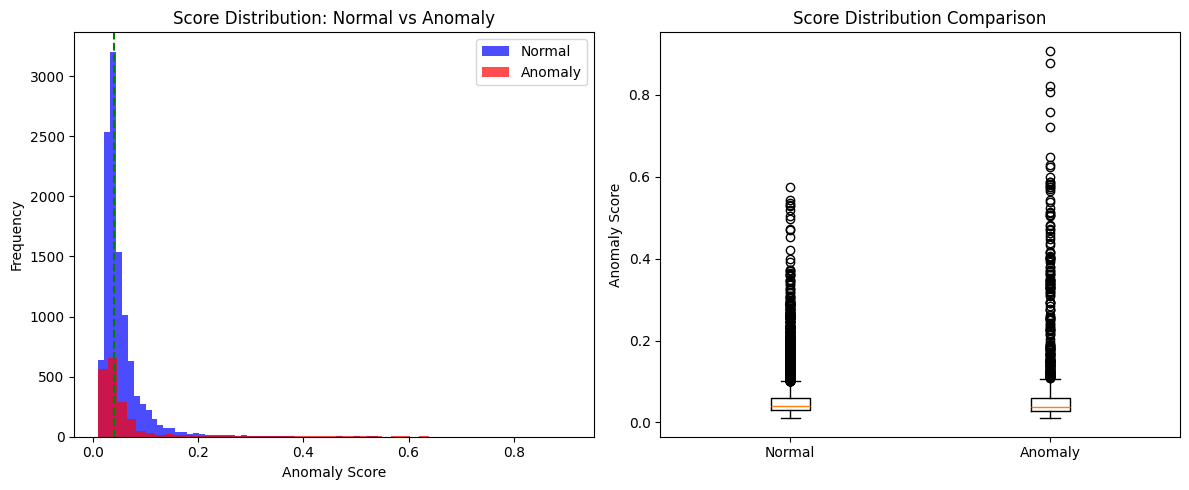

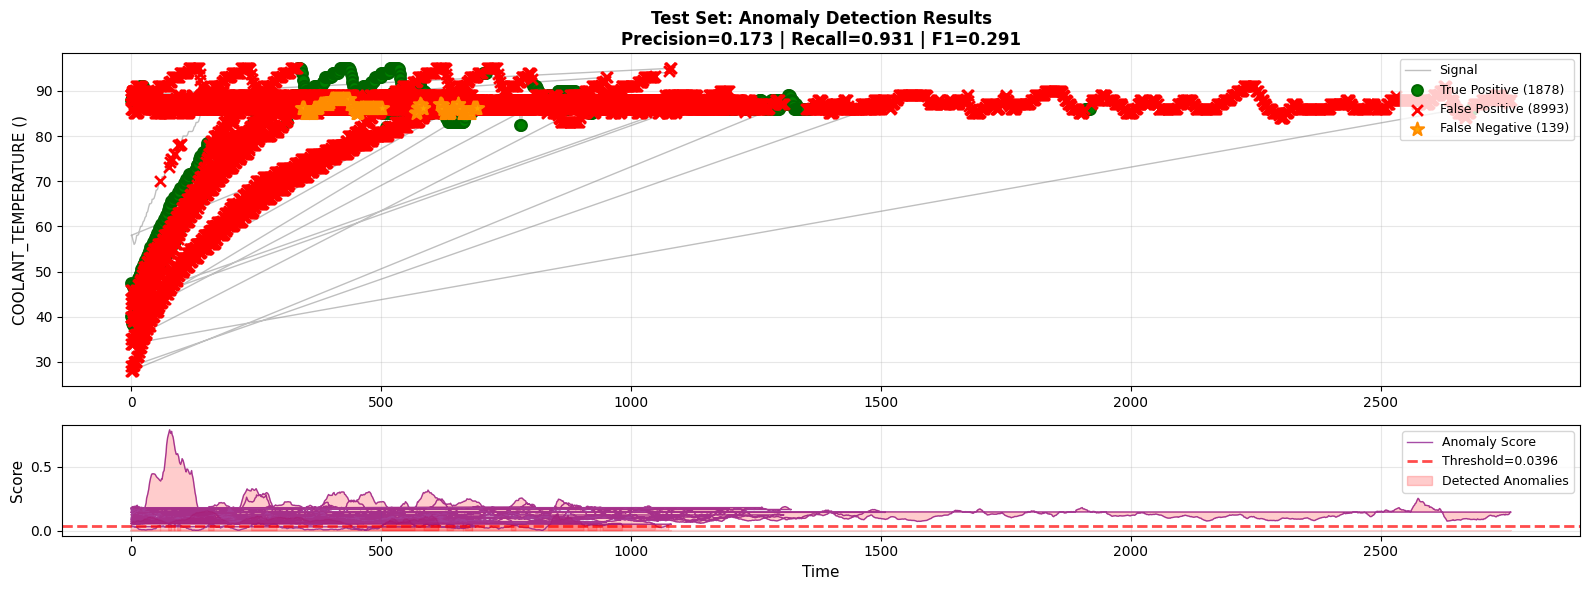


Detection Summary for COOLANT_TEMPERATURE ()
Total points: 11303
True anomalies: 2017 (17.8%)
Detected anomalies: 10871 (96.2%)

True Positives:  1878
False Positives: 8993
False Negatives: 139
True Negatives:  293



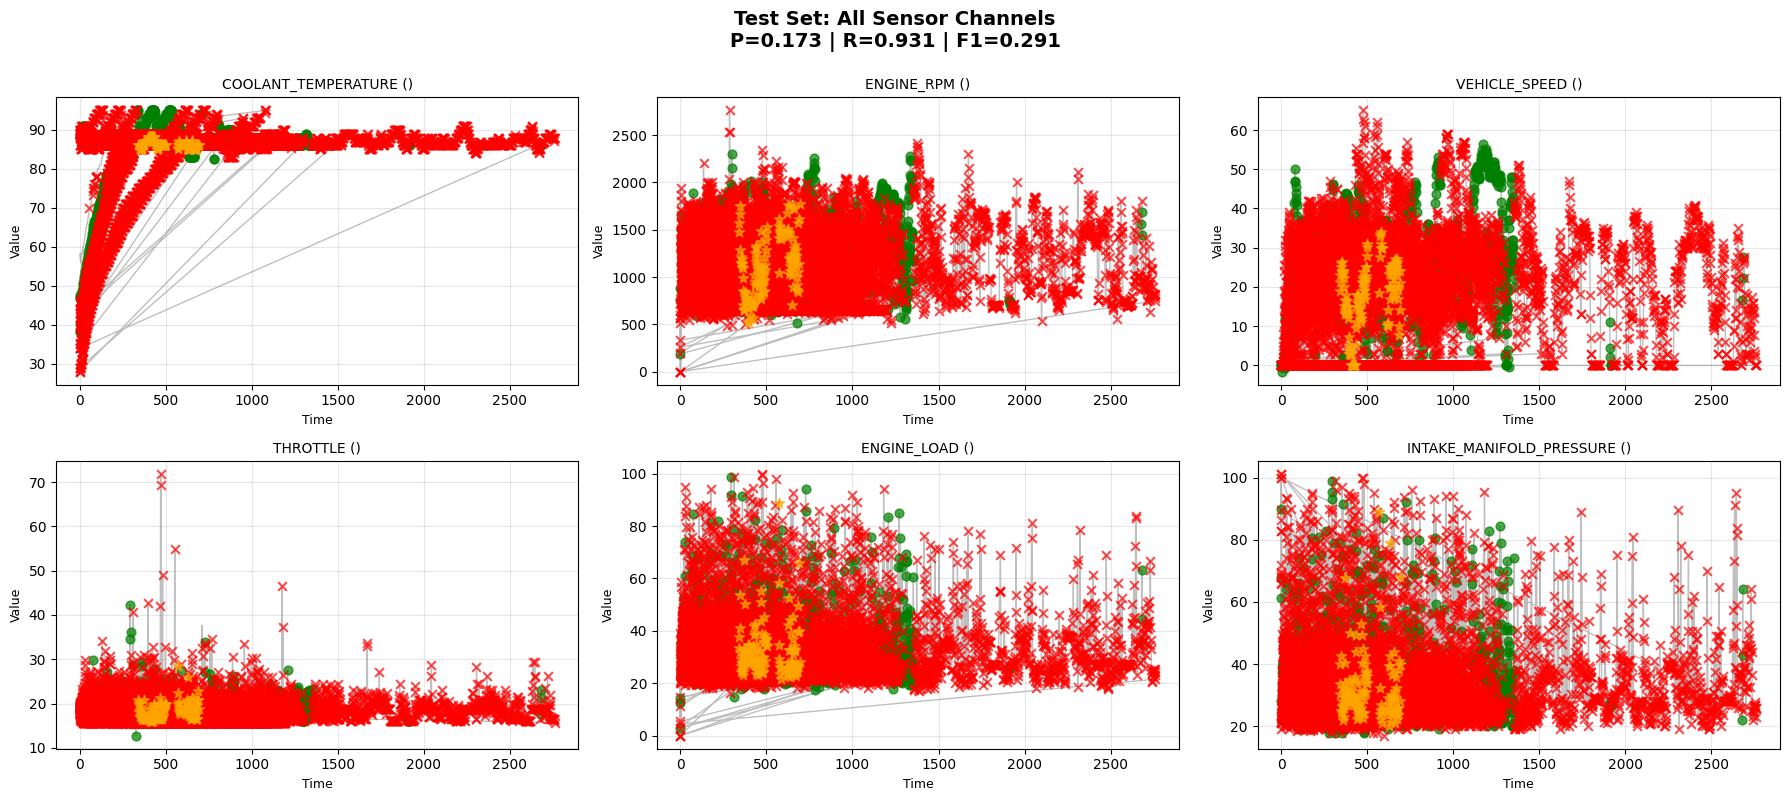


Confusion Matrix:
[[5464 5605]
 [1026  885]]
True Negatives: 5464, False Positives: 5605
False Negatives: 1026, True Positives: 885


In [ ]:
# %%
# Check score distributions
from sklearn.metrics import confusion_matrix


print("=== Anomaly Score Statistics ===")
print(f"Scores - Mean: {val_scores.mean():.4f}, Std: {val_scores.std():.4f}")
print(f"Scores - Min: {val_scores.min():.4f}, Max: {val_scores.max():.4f}")
print(f"True anomalies: {val_true_labels.sum()} / {len(val_true_labels)} ({val_true_labels.mean()*100:.1f}%)")

# %%
# Visualize score distributions for normal vs anomaly
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(val_scores[val_true_labels == 0], bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(val_scores[val_true_labels == 1], bins=50, alpha=0.7, label='Anomaly', color='red')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Score Distribution: Normal vs Anomaly')
plt.legend()
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Threshold={best_threshold:.4f}')

plt.subplot(1, 2, 2)
plt.boxplot([val_scores[val_true_labels == 0], val_scores[val_true_labels == 1]], 
            labels=['Normal', 'Anomaly'])
plt.ylabel('Anomaly Score')
plt.title('Score Distribution Comparison')

plt.tight_layout()
plt.show()

plot_detection_results(
    data_df=test_data_faulty,
    timestamps=test_data_faulty[time_col].values,
    true_labels=test_true_labels,
    predictions=test_preds,
    scores=test_scores,
    threshold=best_threshold,
    value_column="COOLANT_TEMPERATURE ()",
    title="Test Set: Anomaly Detection Results"
)

# %%
# Plot all channels
plot_multiple_channels(
    data_df=test_data_faulty,
    timestamps=test_data_faulty[time_col].values,
    true_labels=test_true_labels,
    predictions=test_preds,
    scores=test_scores,
    threshold=best_threshold,
    channels=target_columns,
    title="Test Set: All Sensor Channels"
)
# %%
# Check confusion matrix
preds = (val_scores > best_threshold).astype(int)
cm = confusion_matrix(val_true_labels, preds)
print("\nConfusion Matrix:")
print(cm)
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")


## Conclusion

The current fault injection methodology is very tailored towards the coolant sensor, which leads to a threshold that is not generalisable to other sensors.

The model performs very well on the coolant sensor, with stable false positives and low false negatives.

An improvement in the coming week would be to inject faults in a generalised way for all target columns. Where statistical and classical machine learning methods fail is identifying drift and gradual wear and tear on sensors. The fault injection mechanism should focus on creating realistic signs of sensor degradation (faulty wiring, broken cross correlations, etc.)

Furthermore, the current threshold optimisation method is not optimal. It optimises a global threshold by looking at the global F2 score. An improvement would be to inspect each channel and use a mean or majority vote to determine the global threshold.

Both of these improvements would lead to a more generalisable model, which is the key issue at this stage.

It should also be noted that some columns have inherent noise and non-stationarity, which is not understood well by the model. For instance, RPM and throttle, which are both related to engine speed, show different pattern which the model does not understand. 

Testing with Robust scaling rather than Standard scaling may improve results, as the model is less affected by outliers.

A promising area of improvement would be to use sliding windows to capture the non-stationarity of the data. IBM get_datasets function supports this, will try with 256 stride (50% of window size) and see if results improve for RPM and throttle.

Downsampling the data could also  help the model understand the data better, but this is a more complex process and would require a lot of domain knowledge.

Replacing the detection pipeline with a network to give an anomaly score based on reconstruction error. This would improve results since we can train this network, and cannot train the current pipeline.